In [ ]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Imports

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import shutil
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

from sklearn.metrics import classification_report, confusion_matrix

Dataset Path + Copy to Local

In [ ]:
# Copy dataset from Google Drive to local runtime
src_train = "/content/drive/My Drive/ai/Scene Classification/Scene Classification/train"
src_test  = "/content/drive/My Drive/ai/Scene Classification/Scene Classification/test"

dst_train = "/content/train_data"
dst_test  = "/content/test_data"

import shutil
import os

if not os.path.exists(dst_train):
    shutil.copytree(src_train, dst_train)

if not os.path.exists(dst_test):
    shutil.copytree(src_test, dst_test)

train_dir = dst_train
test_dir  = dst_test

Dataset Analysis

### Identifying and Removing Invalid Image Files

The `PIL.UnidentifiedImageError` indicates that some files in your dataset directories are not valid image files or are corrupted. The following script will help you find and remove these problematic files from both your training and testing directories.

In [ ]:
import os
from PIL import Image, UnidentifiedImageError
import shutil

def find_and_remove_invalid_images(directory):
    print(f"Scanning directory: {directory}")
    invalid_files = []
    for root, _, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                # Attempt to open and verify the image
                with Image.open(file_path) as img:
                    img.verify()  # Verify that it is an image
                # If verification passes, ensure it's not a zero-byte file
                if os.path.getsize(file_path) == 0:
                    raise UnidentifiedImageError("Zero-byte file")
            except (UnidentifiedImageError, OSError, Image.DecompressionBombError) as e:
                print(f"  Invalid file found: {file_path} (Error: {e})")
                invalid_files.append(file_path)

    if invalid_files:
        print(f"Found {len(invalid_files)} invalid files in {directory}.\n")
        print("Paths of invalid files:")
        for path in invalid_files:
            print(path)

        # Option to remove files
        for path in invalid_files:
            os.remove(path)
        print("Invalid files removed.")
    else:
        print(f"No invalid files found in {directory}.\n")
    return invalid_files

# Run the check for training and testing directories
invalid_train_images = find_and_remove_invalid_images(train_dir)
invalid_test_images = find_and_remove_invalid_images(test_dir)

print("Please review the list of invalid files above. If you are certain these are not valid images, uncomment and run the removal lines in the script above to delete them. After removing, re-run the `ImageDataGenerator` and model training cells.")


Scanning directory: /content/train_data
  Invalid file found: /content/train_data/mountain/17234.jpg (Error: cannot identify image file '/content/train_data/mountain/17234.jpg')
  Invalid file found: /content/train_data/mountain/15696.jpg (Error: cannot identify image file '/content/train_data/mountain/15696.jpg')
  Invalid file found: /content/train_data/mountain/14560.jpg (Error: cannot identify image file '/content/train_data/mountain/14560.jpg')
  Invalid file found: /content/train_data/mountain/16180.jpg (Error: cannot identify image file '/content/train_data/mountain/16180.jpg')
  Invalid file found: /content/train_data/mountain/8725.jpg (Error: cannot identify image file '/content/train_data/mountain/8725.jpg')
  Invalid file found: /content/train_data/mountain/18895.jpg (Error: cannot identify image file '/content/train_data/mountain/18895.jpg')
  Invalid file found: /content/train_data/mountain/15719.jpg (Error: cannot identify image file '/content/train_data/mountain/15719.jp

In [ ]:
total_images = 0

for root, dirs, files in os.walk(train_dir):
    total_images += len(files)

print("Total Images:", total_images)

Total Images: 13993


Sample Images

In [ ]:
import os

class_counts = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print("Class Counts Calculated.")


Class Counts Calculated.


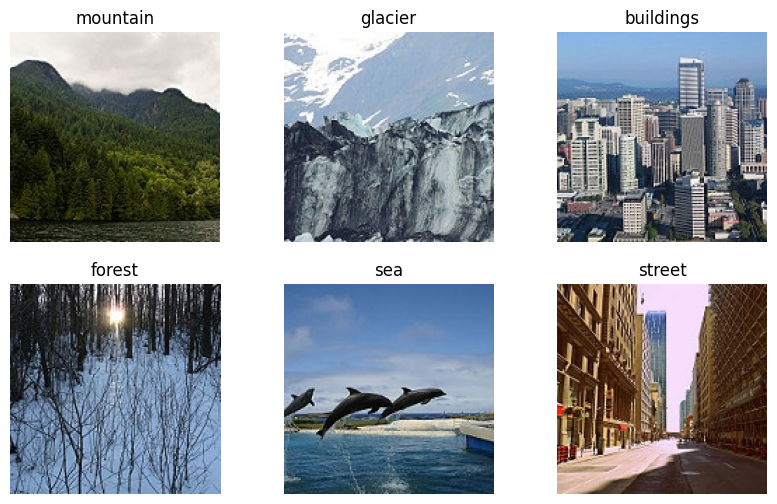

In [ ]:
import matplotlib.pyplot as plt

class_names = list(class_counts.keys())

plt.figure(figsize=(10,6))
for i, class_name in enumerate(class_names[:6]):
    class_path = os.path.join(train_dir, class_name)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.show()

Class Distribution

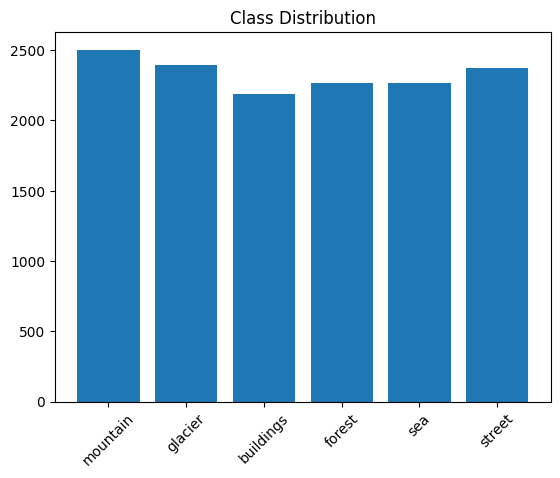

In [ ]:
class_counts = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

Data Preprocessing + Generators

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 11196 images belonging to 6 classes.
Found 2797 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


Sanity Check

In [ ]:
x, y = next(train_generator)
print("Batch shape:", x.shape)

Batch shape: (32, 224, 224, 3)


Baseline CNN Model


- Convolution layers extract spatial features from images.
- Pooling layers reduce dimensionality.
- Fully connected layers perform classification.

Activation function: ReLU  
Output layer: Softmax (for multi-class classification)

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [ ]:
import time


start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

end = time.time()
baseline_time = end - start
print("Baseline Training Time:", baseline_time)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 193s 525ms/step - accuracy: 0.5891 - loss: 1.0453 - val_accuracy: 0.6528 - val_loss: 0.8893
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 172s 493ms/step - accuracy: 0.7059 - loss: 0.7919 - val_accuracy: 0.6661 - val_loss: 0.8192
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 171s 490ms/step - accuracy: 0.7526 - loss: 0.6676 - val_accuracy: 0.7358 - val_loss: 0.7312
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 181s 517ms/step - accuracy: 0.7919 - loss: 0.5795 - val_accuracy: 0.7866 - val_loss: 0.6272
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 170s 486ms/step - accuracy: 0.8123 - loss: 0.5181 - val_accuracy: 0.8266 - val_loss: 0.4954
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 181s 518ms/step - accuracy: 0.8252 - loss: 0.4903 - val_accuracy: 0.8105 - val_loss: 0.5420
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 169s 484ms/step - accuracy: 0.8291 - loss: 0.4736 - val_accuracy: 0.8055 - val_loss: 0.5284
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 174s 497ms/step - accuracy: 0.8425 -

Plot Accuracy & Loss

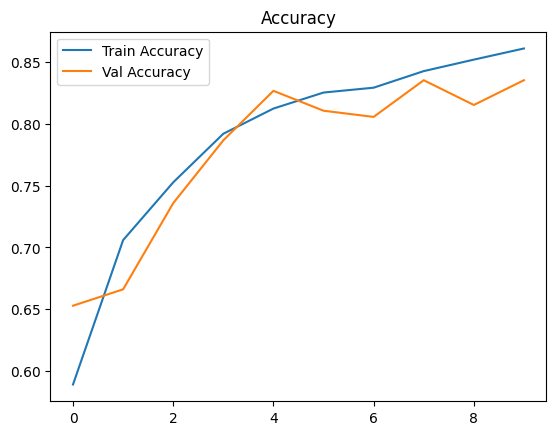

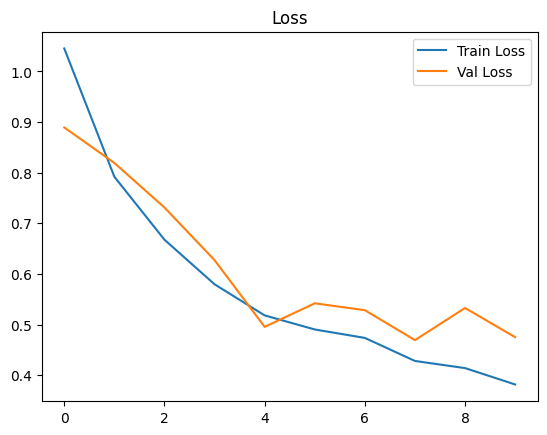

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

Evaluation Metrics

In [ ]:
preds = model.predict(test_generator)
y_pred = preds.argmax(axis=1)

print(classification_report(test_generator.classes, y_pred))

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step
              precision    recall  f1-score   support

           0       0.88      0.74      0.80       437
           1       0.95      0.97      0.96       474
           2       0.88      0.71      0.79       553
           3       0.73      0.87      0.79       525
           4       0.86      0.82      0.84       510
           5       0.79      0.93      0.86       501

    accuracy                           0.84      3000
   macro avg       0.85      0.84      0.84      3000
weighted avg       0.85      0.84      0.84      3000



Deeper Model

In [ ]:
model2 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train Deeper Model

In [ ]:
import time

start = time.time()
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history2 = model2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)
end = time.time()
baseline_time = end - start
print("Baseline Training Time:", baseline_time)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 194s 532ms/step - accuracy: 0.5556 - loss: 1.6498 - val_accuracy: 0.2288 - val_loss: 2.1630
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 182s 520ms/step - accuracy: 0.6707 - loss: 0.8966 - val_accuracy: 0.6271 - val_loss: 1.1243
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 173s 496ms/step - accuracy: 0.7114 - loss: 0.7854 - val_accuracy: 0.6378 - val_loss: 0.9504
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 174s 497ms/step - accuracy: 0.7371 - loss: 0.7202 - val_accuracy: 0.7469 - val_loss: 0.7169
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 172s 493ms/step - accuracy: 0.7584 - loss: 0.6846 - val_accuracy: 0.7361 - val_loss: 0.6983
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 175s 500ms/step - accuracy: 0.7735 - loss: 0.6408 - val_accuracy: 0.6514 - val_loss: 1.2126
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 175s 501ms/step - accuracy: 0.7772 - loss: 0.6201 - val_accuracy: 0.7240 - val_loss: 0.7521
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 174s 496ms/step - accuracy: 0.7893 -

Optimizer Comparison

> Adam converges faster and provides better accuracy compared to SGD.  
SGD may require more epochs but can generalize better in some cases.



Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 190s 533ms/step - accuracy: 0.6225 - loss: 1.0974 - val_accuracy: 0.4190 - val_loss: 2.2053
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 174s 496ms/step - accuracy: 0.7219 - loss: 0.7577 - val_accuracy: 0.7000 - val_loss: 0.8367
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 176s 504ms/step - accuracy: 0.7703 - loss: 0.6407 - val_accuracy: 0.7294 - val_loss: 0.7539
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 171s 489ms/step - accuracy: 0.7888 - loss: 0.5755 - val_accuracy: 0.6975 - val_loss: 0.8382
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 175s 499ms/step - accuracy: 0.8051 - loss: 0.5261 - val_accuracy: 0.7340 - val_loss: 0.7681
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 172s 492ms/step - accuracy: 0.8249 - loss: 0.4827 - val_accuracy: 0.7404 - val_loss: 0.7928
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 174s 497ms/step - accuracy: 0.8366 - loss: 0.4555 - val_accuracy: 0.7862 - val_loss: 0.6354
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 172s 492ms/step - accuracy: 0.8467 -

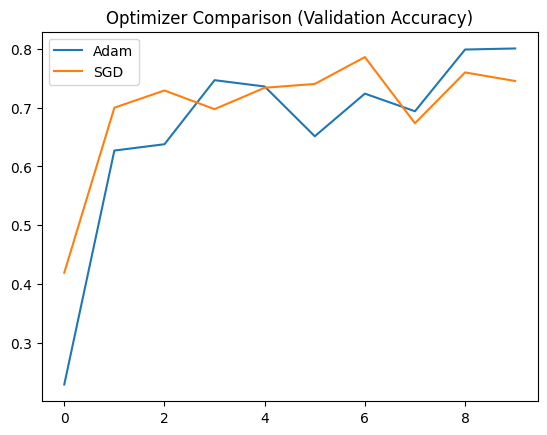

In [ ]:

# Reuse deeper model architecture
model_sgd = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(6, activation='softmax')
])

# Compile with SGD
model_sgd.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_sgd = model_sgd.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

# Plot comparison
plt.plot(history2.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')

plt.title("Optimizer Comparison (Validation Accuracy)")
plt.legend()
plt.show()

Ablation Study

Removing dropout led to increased overfitting.  
Dropout helps improve generalization by preventing the model from memorizing training data.

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 180s 499ms/step - accuracy: 0.4957 - loss: 5.6415 - val_accuracy: 0.2678 - val_loss: 20.6038
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 171s 490ms/step - accuracy: 0.5548 - loss: 1.2360 - val_accuracy: 0.5756 - val_loss: 1.2517
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 173s 496ms/step - accuracy: 0.6105 - loss: 1.0503 - val_accuracy: 0.6553 - val_loss: 0.9497
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 177s 507ms/step - accuracy: 0.6763 - loss: 0.8966 - val_accuracy: 0.6954 - val_loss: 0.9325
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 172s 491ms/step - accuracy: 0.7122 - loss: 0.8205 - val_accuracy: 0.6854 - val_loss: 0.8925
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 174s 497ms/step - accuracy: 0.7241 - loss: 0.7710 - val_accuracy: 0.7336 - val_loss: 0.7986
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 172s 492ms/step - accuracy: 0.7456 - loss: 0.7230 - val_accuracy: 0.7147 - val_loss: 0.8531
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 175s 501ms/step - accuracy: 0.7684 

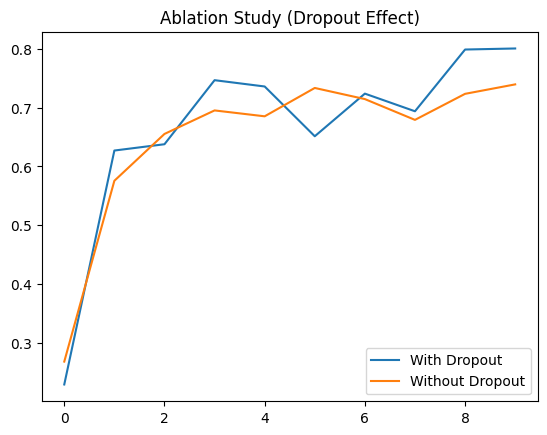

In [ ]:

model_no_dropout = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(6, activation='softmax')
])

model_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_no_dropout = model_no_dropout.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

# Compare
plt.plot(history2.history['val_accuracy'], label='With Dropout')
plt.plot(history_no_dropout.history['val_accuracy'], label='Without Dropout')

plt.title("Ablation Study (Dropout Effect)")
plt.legend()
plt.show()

Transfer Learning

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense
import time


# Load Pretrained Model


base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classifier
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(6, activation='softmax')(x)

model3 = Model(inputs=base_model.input, outputs=output)

# Compile
model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Training (Feature Extraction)


start = time.time()

history3 = model3.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

end = time.time()
transfer_time = end - start

print("Transfer Learning Time:", transfer_time)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 239s 630ms/step - accuracy: 0.7963 - loss: 0.6212 - val_accuracy: 0.8194 - val_loss: 0.5277
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 196s 560ms/step - accuracy: 0.8659 - loss: 0.3717 - val_accuracy: 0.8595 - val_loss: 0.3919
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 199s 570ms/step - accuracy: 0.8795 - loss: 0.3304 - val_accuracy: 0.8702 - val_loss: 0.3606
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 198s 566ms/step - accuracy: 0.8905 - loss: 0.3038 - val_accuracy: 0.8784 - val_loss: 0.3450
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 196s 560ms/step - accuracy: 0.8991 - loss: 0.2712 - val_accuracy: 0.8373 - val_loss: 0.4623
Transfer Learning Time: 1035.0986785888672


Confusion Matrix


The confusion matrix shows the number of correct and incorrect predictions for each class.

Diagonal values represent correct classifications, while off-diagonal values indicate misclassifications.

This helps identify which classes the model confuses (e.g., mountain vs glacier).

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.74      0.80       437
           1       0.95      0.97      0.96       474
           2       0.88      0.71      0.79       553
           3       0.73      0.87      0.79       525
           4       0.86      0.82      0.84       510
           5       0.79      0.93      0.86       501

    accuracy                           0.84      3000
   macro avg       0.85      0.84      0.84      3000
weighted avg       0.85      0.84      0.84      3000



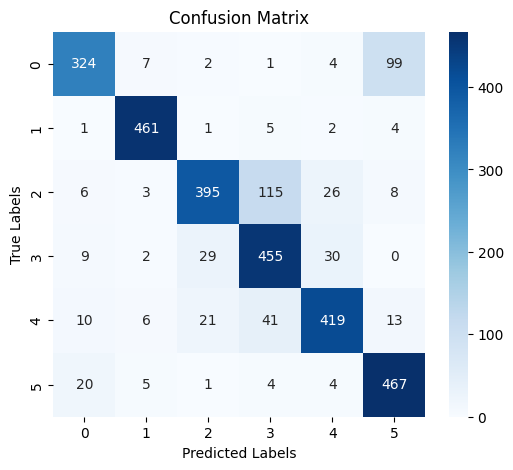

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preds = model.predict(test_generator)
y_pred = preds.argmax(axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(test_generator.classes, y_pred))

# Confusion Matrix
cm = confusion_matrix(test_generator.classes, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()